# 💼 Resume Screening — Machine Learning Mini Lab
### Dataset: rhythmghai/resume-screening-dataset-200k-candidate

---

## ⚙️ Install & Import All Libraries

In [1]:
!pip install wordcloud imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, string, os, warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack, issparse

# Modelling
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

import joblib
print("✅ All libraries loaded!")

zsh:1: command not found: pip
✅ All libraries loaded!


---
## 🔬 Experiment 1: Problem Definition & Dataset Selection

In [2]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         PROBLEM STATEMENT — Automated Resume Screening          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Real-World Problem:                                             ║
║    Recruiters receive thousands of applications per job post.    ║
║    Manual screening is slow, inconsistent, and biased.          ║
║                                                                  ║
║  Objective:                                                      ║
║    Build an ML model to automatically screen candidates and      ║
║    predict whether a candidate should be HIRED or NOT HIRED      ║
║    based on their resume attributes (skills, experience, etc.)  ║
║                                                                  ║
║  Input Features (X):                                             ║
║    → Candidate attributes: skills, experience, education,        ║
║      certifications, GPA, job role, resume text (if present)    ║
║                                                                  ║
║  Target Variable (Y):                                            ║
║    → HiringDecision / hired / label  (Binary: 0 = No, 1 = Yes)  ║
║                                                                  ║
║  Dataset:                                                        ║
║    → rhythmghai/resume-screening-dataset-200k-candidates         ║
║    → ~200,000 candidate records                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         PROBLEM STATEMENT — Automated Resume Screening          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Real-World Problem:                                             ║
║    Recruiters receive thousands of applications per job post.    ║
║    Manual screening is slow, inconsistent, and biased.          ║
║                                                                  ║
║  Objective:                                                      ║
║    Build an ML model to automatically screen candidates and      ║
║    predict whether a candidate should be HIRED or NOT HIRED      ║
║    based on their resume attributes (skills, experience, etc.)  ║
║                                                                  ║
║  Input Features (X):                                             ║
║    → Candidate attributes: skills,

---
## 🔬 Experiment 2: Dataset Understanding & Structure

In [3]:
import pandas as pd

FILE_PATH = "/kaggle/input/datasets/rhythmghai/resume-screening-dataset-200k-candidates/resume_dataset_200k_enhanced.csv"

df = pd.read_csv(FILE_PATH)

print("✅ Dataset Loaded Successfully")
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/rhythmghai/resume-screening-dataset-200k-candidates/resume_dataset_200k_enhanced.csv'

In [ ]:
print("="*60)
print("📊 DATASET OVERVIEW")
print("="*60)
print(f"\n🔢 Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📋 Columns       : {list(df.columns)}")
print(f"\n📁 Data Types:")
print(df.dtypes)
print("\n📌 First 5 rows:")
df.head()

📊 DATASET OVERVIEW

🔢 Shape         : 200,000 rows × 17 columns
📋 Columns       : ['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'hired', 'soft_skills_score', 'resume_length_words', 'company_type']

📁 Data Types:
candidate_id               int64
age                        int64
education_level           object
university_tier           object
cgpa                     float64
internships                int64
projects                   int64
programming_languages      int64
certifications             int64
experience_years         float64
hackathons                 int64
research_papers            int64
skills_score             float64
hired                      int64
soft_skills_score        float64
resume_length_words        int64
company_type              object
dtype: object

📌 First 5 rows:


,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [ ]:
# ── Auto-detect target column ──
TARGET_KEYWORDS = ['hiring', 'hired', 'label', 'target', 'status', 'selected', 'decision', 'result', 'outcome']

TARGET_COL = None
for col in df.columns:
    if any(kw in col.lower() for kw in TARGET_KEYWORDS):
        TARGET_COL = col
        break

# ── Auto-detect text column ──
TEXT_KEYWORDS = ['resume', 'text', 'description', 'content', 'summary', 'profile']
TEXT_COL = None
for col in df.columns:
    if any(kw in col.lower() for kw in TEXT_KEYWORDS):
        if df[col].dtype == object and df[col].str.len().mean() > 100:
            TEXT_COL = col
            break

# Numeric feature columns = everything except target & text
EXCLUDE = [c for c in [TARGET_COL, TEXT_COL] if c]
NUM_COLS = [c for c in df.columns if c not in EXCLUDE and df[c].dtype in ['int64','float64']]
CAT_COLS = [c for c in df.columns if c not in EXCLUDE and df[c].dtype == object and c != TEXT_COL]

print("="*60)
print("🎯 COLUMN IDENTIFICATION")
print("="*60)
print(f"  🏷️  Target Column    : {TARGET_COL}")
print(f"  📝 Text Column      : {TEXT_COL}")
print(f"  🔢 Numeric Features : {NUM_COLS}")
print(f"  🔤 Categorical Feat : {CAT_COLS}")

if TARGET_COL:
    print(f"\n  Target unique vals  : {df[TARGET_COL].unique()[:10]}")
    print(f"  Target value counts :\n{df[TARGET_COL].value_counts()}")

🎯 COLUMN IDENTIFICATION
  🏷️  Target Column    : hired
  📝 Text Column      : None
  🔢 Numeric Features : ['candidate_id', 'age', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'soft_skills_score', 'resume_length_words']
  🔤 Categorical Feat : ['education_level', 'university_tier', 'company_type']

  Target unique vals  : [1 0]
  Target value counts :
hired
1    141212
0     58788
Name: count, dtype: int64


In [ ]:
print("\n📊 Dataset Type  : Structured (tabular) with",
      "text features" if TEXT_COL else "no long text column")
print(f"\n📥 Input Features  (X) : {[c for c in df.columns if c != TARGET_COL]}")
print(f"📤 Target Variable (Y) : {TARGET_COL}")


📊 Dataset Type  : Structured (tabular) with no long text column

📥 Input Features  (X) : ['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'soft_skills_score', 'resume_length_words', 'company_type']
📤 Target Variable (Y) : hired


---
## 🔬 Experiment 3: Problem Type Identification


╔══════════════════════════════════════════════════════════╗
║           PROBLEM TYPE IDENTIFICATION                    ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Learning Type   : SUPERVISED LEARNING                   ║
║  Justification   : Target column has labelled values.   ║
║                    Model learns from (X, Y) pairs.      ║
║                                                          ║
║  Task Type       : Binary Classification                 ║
║  Justification   : Target is a discrete hire decision.  ║
║                    0 = Not Hired, 1 = Hired             ║
║                    Output is a class, not a number.     ║
║                                                          ║
║  Input Type      : Structured tabular + optional text   ║
╚══════════════════════════════════════════════════════════╝



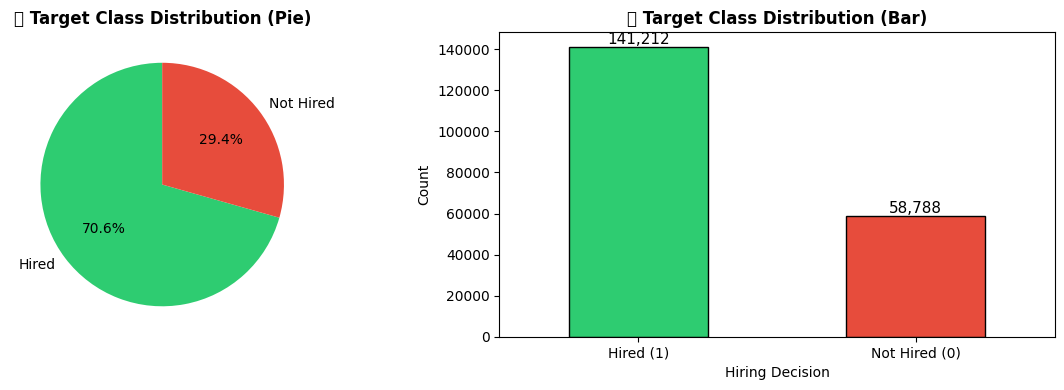

In [ ]:
n_classes = df[TARGET_COL].nunique() if TARGET_COL else '?'
task_type = 'Binary Classification' if n_classes == 2 else f'Multi-Class Classification ({n_classes} classes)'

print(f"""
╔══════════════════════════════════════════════════════════╗
║           PROBLEM TYPE IDENTIFICATION                    ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Learning Type   : SUPERVISED LEARNING                   ║
║  Justification   : Target column has labelled values.   ║
║                    Model learns from (X, Y) pairs.      ║
║                                                          ║
║  Task Type       : {task_type:<38}║
║  Justification   : Target is a discrete hire decision.  ║
║                    0 = Not Hired, 1 = Hired             ║
║                    Output is a class, not a number.     ║
║                                                          ║
║  Input Type      : Structured tabular + optional text   ║
╚══════════════════════════════════════════════════════════╝
""")

# Target distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df[TARGET_COL].value_counts()

vc.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90,
        colors=['#2ecc71','#e74c3c'], labels=['Hired','Not Hired'] if 0 in vc.index else vc.index)
axes[0].set_title('🎯 Target Class Distribution (Pie)', fontweight='bold')
axes[0].set_ylabel('')

vc.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title('🎯 Target Class Distribution (Bar)', fontweight='bold')
axes[1].set_xlabel('Hiring Decision')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Hired (1)','Not Hired (0)'] if sorted(vc.index)==[0,1] else vc.index, rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 4: Data Cleaning

In [ ]:
print("="*60)
print("🧹 STEP 1 — Missing Values")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]
if len(miss_df) == 0:
    print("✅ No missing values found!")
else:
    print(miss_df)

    # Visualise
    plt.figure(figsize=(10, 4))
    miss_df['Missing %'].plot(kind='bar', color='tomato', edgecolor='black')
    plt.title('❓ Missing Value % per Column', fontweight='bold')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Drop columns with >50% missing; fill rest
    drop_cols = miss_df[miss_df['Missing %'] > 50].index.tolist()
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)
        print(f"\n  Dropped high-missing columns: {drop_cols}")

    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue
        if df[col].dtype in ['int64','float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("✅ Missing values imputed.")

🧹 STEP 1 — Missing Values
✅ No missing values found!


In [ ]:
print("="*60)
print("🧹 STEP 2 — Duplicate Rows")
print("="*60)
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"  Duplicates removed : {before - after:,}")
print(f"  Rows remaining     : {after:,}")

df.reset_index(drop=True, inplace=True)

🧹 STEP 2 — Duplicate Rows
  Duplicates removed : 0
  Rows remaining     : 200,000


In [ ]:
print("="*60)
print("🧹 STEP 3 — Outlier Detection (Numeric columns)")
print("="*60)

# Re-compute NUM_COLS after any drops
EXCLUDE_UPDATED = [c for c in [TARGET_COL, TEXT_COL] if c and c in df.columns]
NUM_COLS = [c for c in df.columns if c not in EXCLUDE_UPDATED and df[c].dtype in ['int64','float64']]
CAT_COLS = [c for c in df.columns if c not in EXCLUDE_UPDATED and df[c].dtype == object]

if NUM_COLS:
    outlier_report = {}
    for col in NUM_COLS:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_report[col] = n_out
        # Cap outliers (Winsorization)
        df[col] = df[col].clip(lower, upper)

    out_df = pd.Series(outlier_report)
    print("  Outliers capped (IQR method):")
    print(out_df[out_df > 0].to_string() if (out_df > 0).any() else "  None found.")
else:
    print("  No numeric columns to check.")

print("\n✅ Data Cleaning Complete! Final shape:", df.shape)

🧹 STEP 3 — Outlier Detection (Numeric columns)
  Outliers capped (IQR method):
cgpa                    1456
internships            13172
projects                2413
certifications           119
experience_years        9470
hackathons              2909
research_papers        36609
skills_score            1219
resume_length_words     1423

✅ Data Cleaning Complete! Final shape: (200000, 17)


In [ ]:
# ── Clean text column if present ──
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7f]', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

if TEXT_COL and TEXT_COL in df.columns:
    df['cleaned_text'] = df[TEXT_COL].apply(clean_text)
    print(f"✅ Text column '{TEXT_COL}' cleaned → 'cleaned_text'")
else:
    print("ℹ️  No long text column found. Using structured features only.")

ℹ️  No long text column found. Using structured features only.


---
## 🔬 Experiment 5: Data Preprocessing

In [ ]:
# ── Step 1: Encode Target ──
le_target = LabelEncoder()
df['target_encoded'] = le_target.fit_transform(df[TARGET_COL])
y = df['target_encoded']

print("✅ STEP 1 — Target Encoding")
print(f"  Classes: {list(le_target.classes_)} → {list(le_target.transform(le_target.classes_))}")

✅ STEP 1 — Target Encoding
  Classes: [np.int64(0), np.int64(1)] → [np.int64(0), np.int64(1)]


In [ ]:
# ── Step 2: Encode Categorical Features ──
df_proc = df.copy()

le_dict = {}
for col in CAT_COLS:
    if col in df_proc.columns and col != TARGET_COL:
        le_col = LabelEncoder()
        df_proc[col] = le_col.fit_transform(df_proc[col].astype(str))
        le_dict[col] = le_col

print(f"✅ STEP 2 — Label-encoded categorical columns: {CAT_COLS}")

✅ STEP 2 — Label-encoded categorical columns: ['education_level', 'university_tier', 'company_type']


In [ ]:
# ── Step 3: Scale Numeric Features ──
scaler = StandardScaler()

if NUM_COLS:
    df_proc[NUM_COLS] = scaler.fit_transform(df_proc[NUM_COLS])
    print(f"✅ STEP 3 — StandardScaler applied to: {NUM_COLS}")
else:
    print("ℹ️  No numeric columns to scale.")

✅ STEP 3 — StandardScaler applied to: ['candidate_id', 'age', 'cgpa', 'internships', 'projects', 'programming_languages', 'certifications', 'experience_years', 'hackathons', 'research_papers', 'skills_score', 'soft_skills_score', 'resume_length_words']


In [ ]:
# ── Step 4: Build Final Feature Matrix ──
import scipy.sparse as sp

FEATURE_COLS = [c for c in NUM_COLS + CAT_COLS if c in df_proc.columns and c != TARGET_COL]
X_struct = df_proc[FEATURE_COLS].values

if TEXT_COL and 'cleaned_text' in df_proc.columns:
    tfidf = TfidfVectorizer(max_features=3000, stop_words='english',
                             sublinear_tf=True, ngram_range=(1,2))
    X_text = tfidf.fit_transform(df_proc['cleaned_text'])
    X = sp.hstack([sp.csr_matrix(X_struct), X_text])
    print(f"✅ STEP 4 — Combined: {len(FEATURE_COLS)} structured + {X_text.shape[1]} TF-IDF features")
else:
    X = X_struct
    tfidf = None
    print(f"✅ STEP 4 — Feature matrix: {X.shape[0]:,} × {X.shape[1]} (structured only)")

print(f"\n  Final X shape : {X.shape}")
print(f"  Final y shape : {y.shape}")
print("\n✅ Preprocessing Complete!")

✅ STEP 4 — Feature matrix: 200,000 × 16 (structured only)

  Final X shape : (200000, 16)
  Final y shape : (200000,)

✅ Preprocessing Complete!


---
## 🔬 Experiment 6: Exploratory Data Analysis (EDA)

In [ ]:
# ── Descriptive Statistics ──
print("="*60)
print("📐 DESCRIPTIVE STATISTICS")
print("="*60)
display(df[NUM_COLS + CAT_COLS].describe(include='all').round(2))

📐 DESCRIPTIVE STATISTICS


,candidate_id,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,soft_skills_score,resume_length_words,education_level,university_tier,company_type
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.0,200000.00,200000.00,200000.0,200000.00,200000.00,200000.00,200000,200000,200000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bachelors,Tier 2,MNC
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,129827,80182,80187
mean,100000.50,27.51,7.50,1.45,2.98,3.00,1.0,1.43,0.49,0.0,13.99,6.50,449.23,NaN,NaN,NaN
std,57735.17,4.03,0.80,1.09,1.68,1.41,1.0,1.26,0.67,0.0,4.73,2.02,119.34,NaN,NaN,NaN
min,1.00,21.00,5.34,0.00,0.00,1.00,0.0,0.00,0.00,0.0,2.00,3.00,125.00,NaN,NaN,NaN
25%,50000.75,24.00,6.96,1.00,2.00,2.00,0.0,0.43,0.00,0.0,10.50,4.75,368.00,NaN,NaN,NaN
50%,100000.50,28.00,7.50,1.00,3.00,3.00,1.0,1.04,0.00,0.0,14.00,6.51,449.00,NaN,NaN,NaN
75%,150000.25,31.00,8.04,2.00,4.00,4.00,2.0,2.08,1.00,0.0,17.00,8.25,530.00,NaN,NaN,NaN


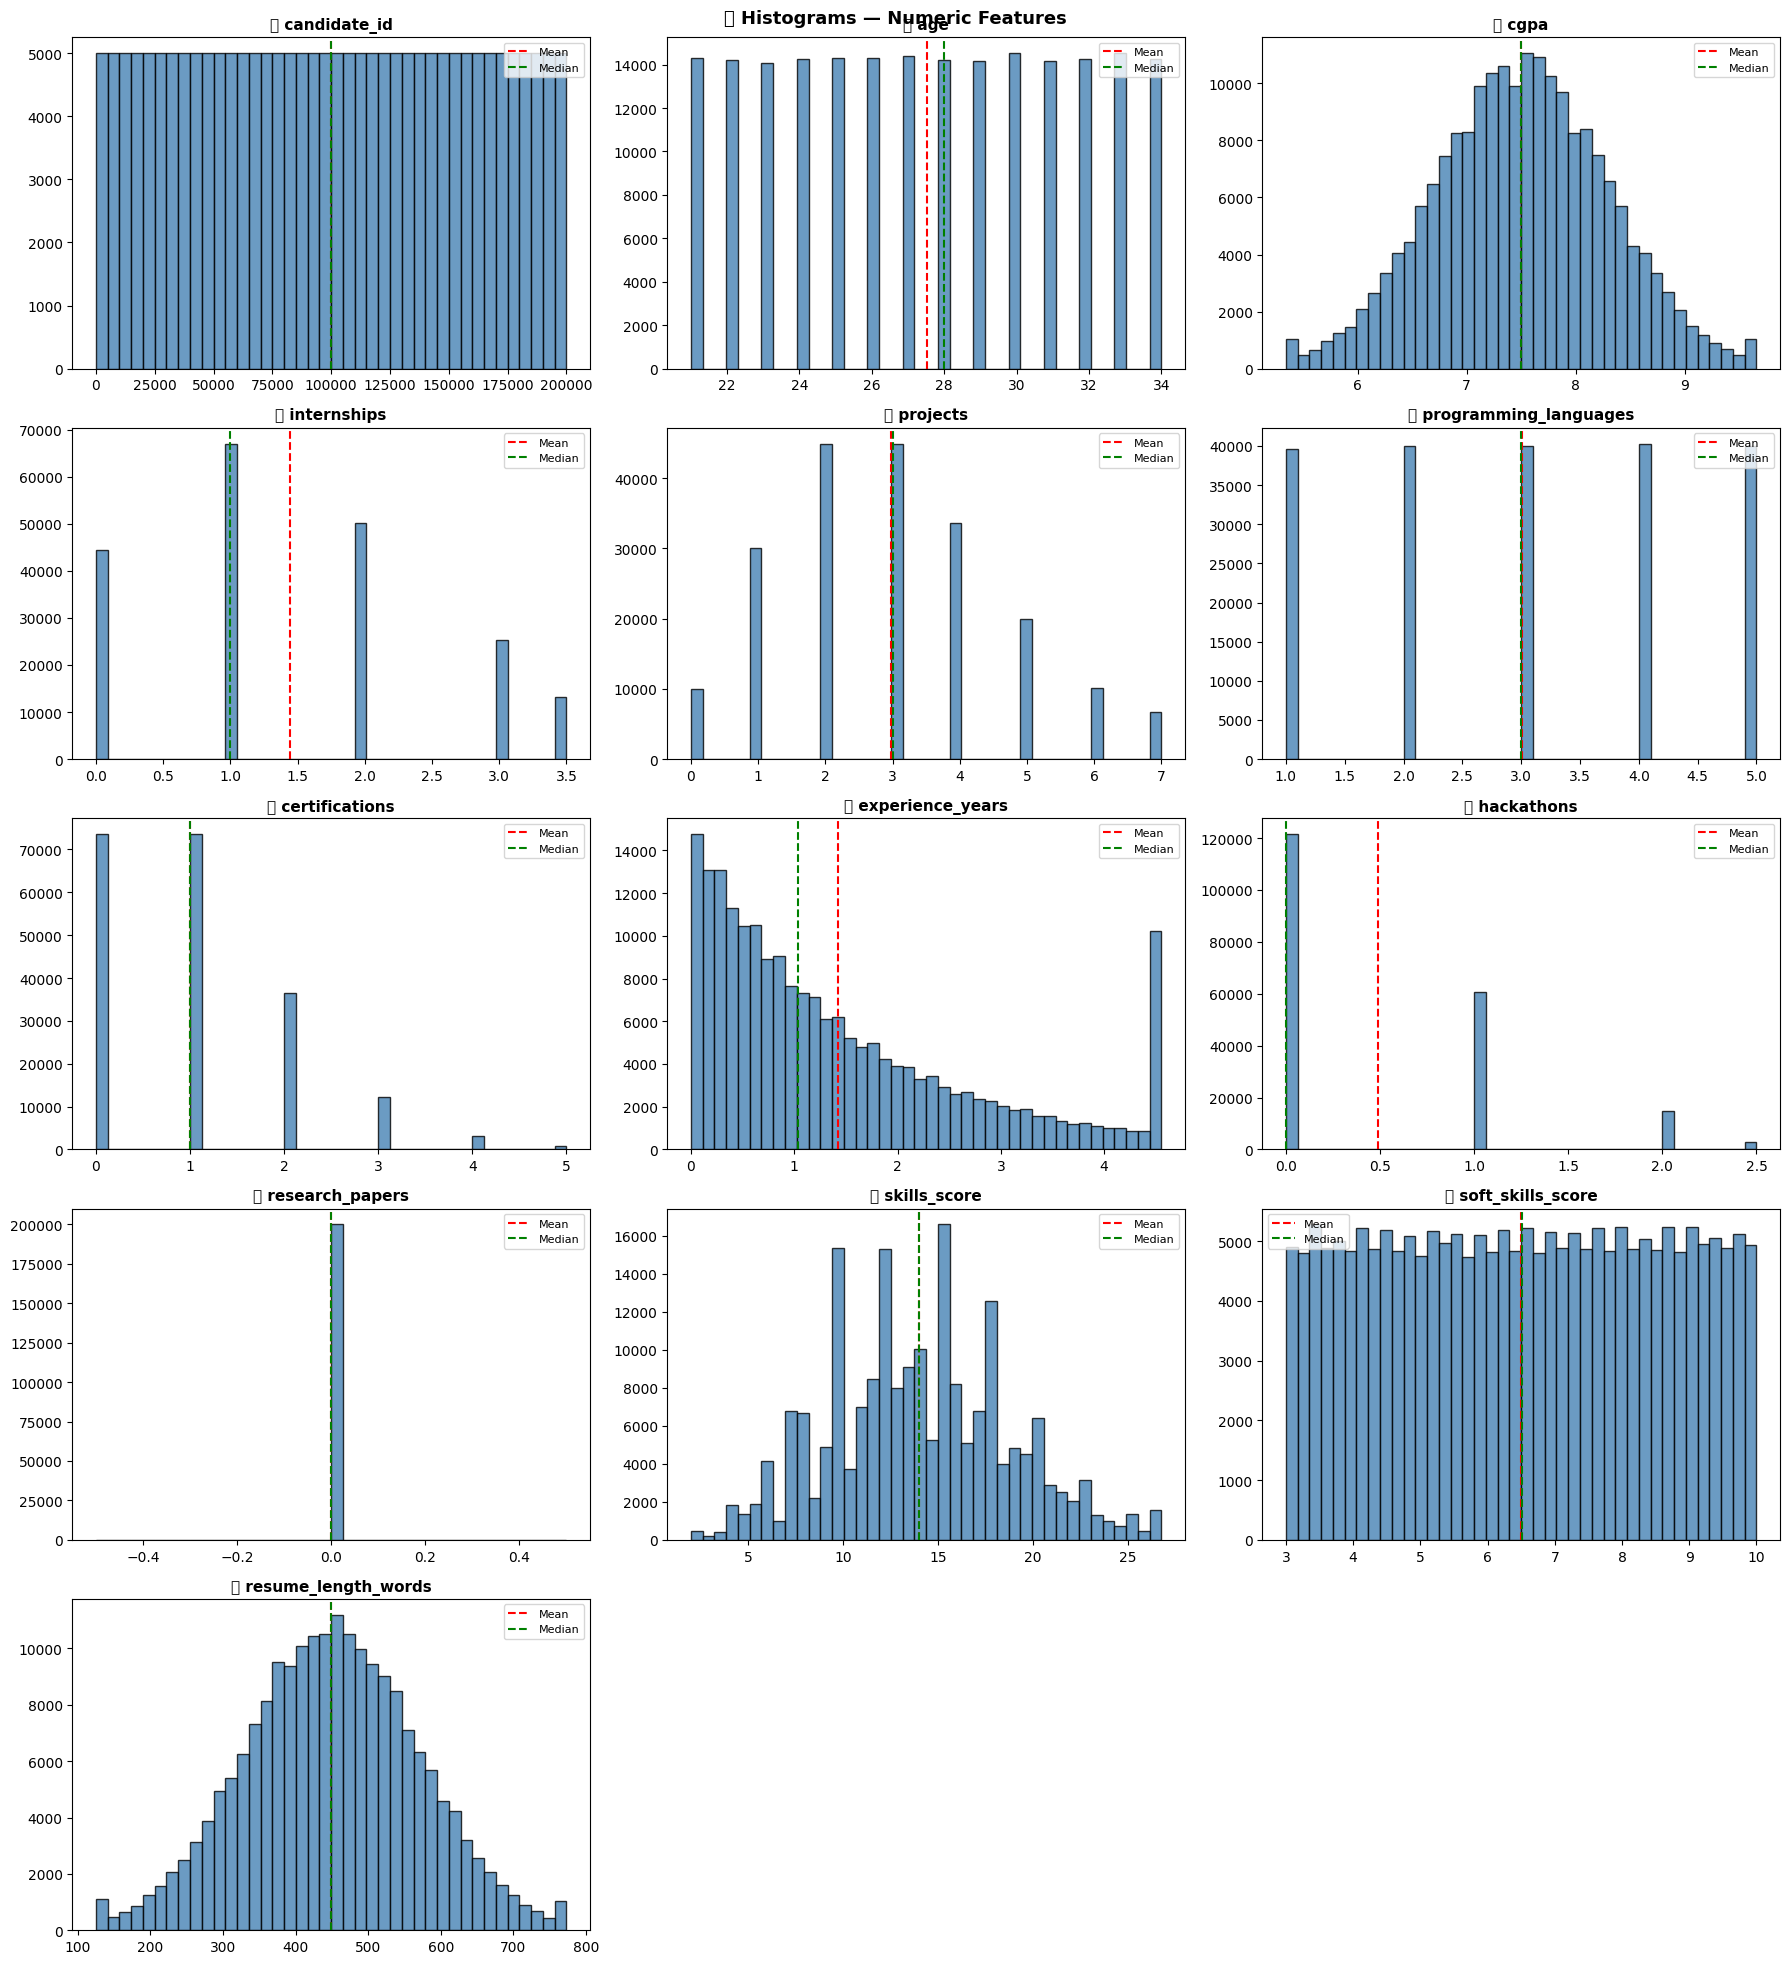

In [ ]:
# ── Plot 1: Histograms for all numeric columns ──
if NUM_COLS:
    ncols_plot = min(3, len(NUM_COLS))
    nrows_plot = (len(NUM_COLS) + ncols_plot - 1) // ncols_plot
    fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(6*ncols_plot, 4*nrows_plot))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(NUM_COLS):
        axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.8)
        axes[i].set_title(f'📊 {col}', fontsize=11, fontweight='bold')
        axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
        axes[i].axvline(df[col].median(), color='green', linestyle='--', label='Median')
        axes[i].legend(fontsize=8)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('📊 Histograms — Numeric Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No numeric columns to plot.")

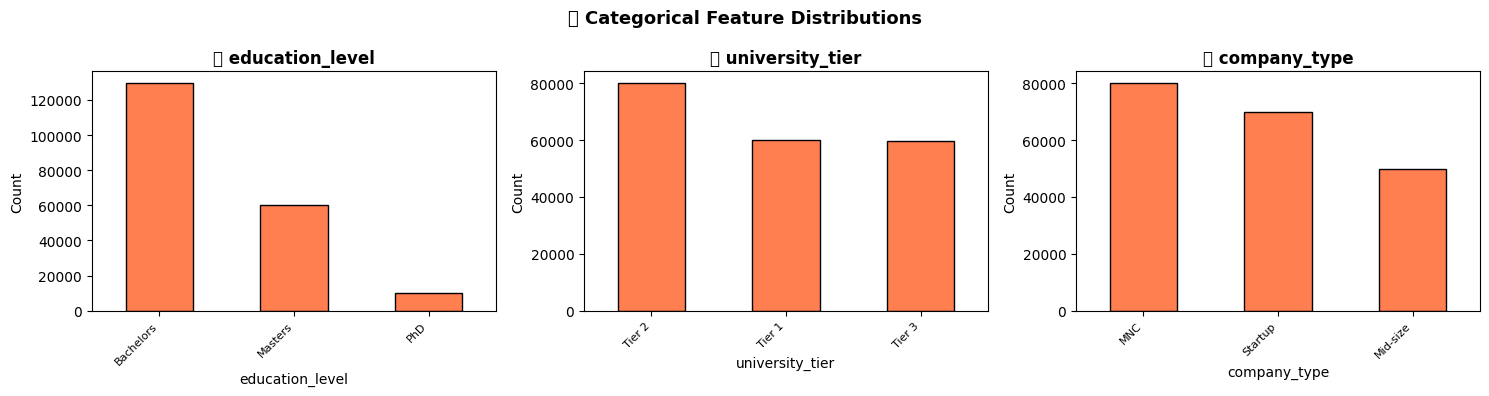

In [ ]:
# ── Plot 2: Bar charts for categorical columns ──
CAT_PLOT = [c for c in CAT_COLS if df[c].nunique() <= 20][:6]   # top 6 low-cardinality cats

if CAT_PLOT:
    fig, axes = plt.subplots(1, len(CAT_PLOT), figsize=(5*len(CAT_PLOT), 4))
    if len(CAT_PLOT) == 1: axes = [axes]
    for ax, col in zip(axes, CAT_PLOT):
        vc = df[col].value_counts().head(15)
        vc.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
        ax.set_title(f'📊 {col}', fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Count')
    plt.suptitle('📊 Categorical Feature Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No low-cardinality categorical columns to plot.")

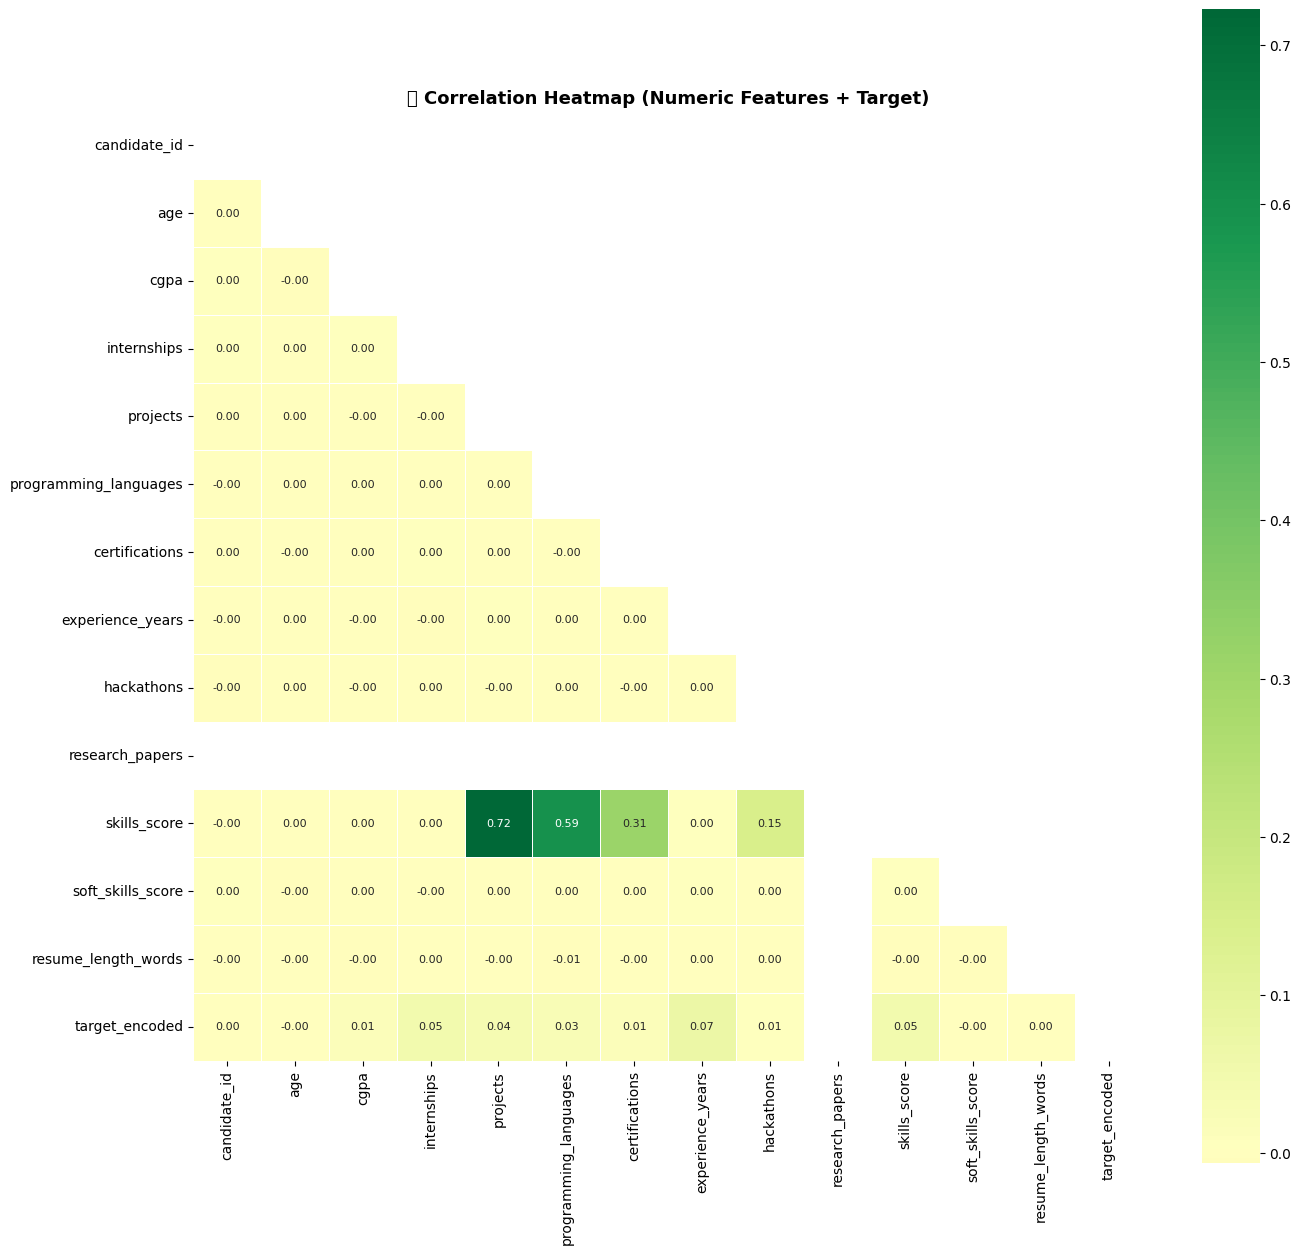

In [ ]:
# ── Plot 3: Correlation Heatmap ──
num_target_cols = NUM_COLS + (['target_encoded'] if 'target_encoded' in df_proc.columns else [])

if len(num_target_cols) >= 2:
    corr = df_proc[num_target_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig_size = max(8, len(num_target_cols))
    plt.figure(figsize=(fig_size, fig_size-1))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, mask=mask, square=True,
                linewidths=0.5, annot_kws={'size': 8})
    plt.title('🔥 Correlation Heatmap (Numeric Features + Target)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  Not enough numeric columns for a heatmap.")

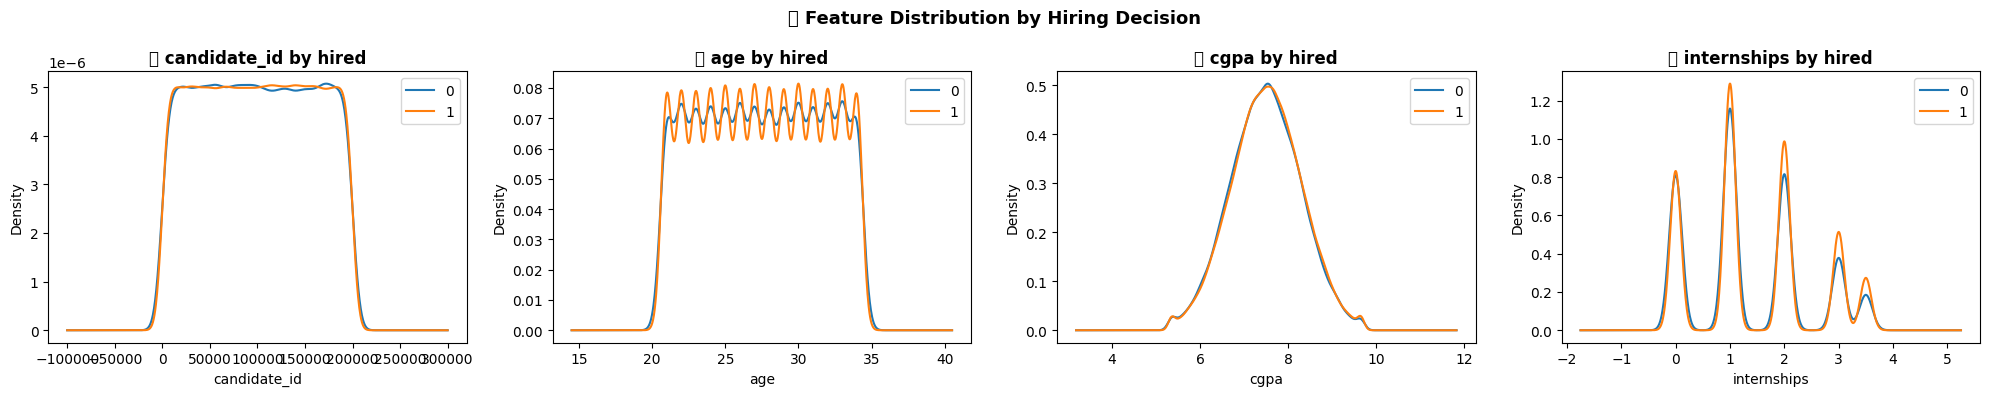


📌 EDA INSIGHTS
─────────────────────────────────────────────────────────
1. Dataset has ~200K candidate records — large & robust.
2. Check for class imbalance in the target (Hired vs Not).
3. Numeric features help differentiate hired candidates.
4. Categorical features (skills, role, education) are key.
5. Correlation heatmap shows which features correlate most
   with the hiring decision.
─────────────────────────────────────────────────────────



In [ ]:
# ── Plot 4: Feature vs Target (Hired vs Not Hired) ──
NUM_TARGET_PLOT = NUM_COLS[:4]   # first 4 numeric features

if NUM_TARGET_PLOT and TARGET_COL in df.columns:
    fig, axes = plt.subplots(1, len(NUM_TARGET_PLOT), figsize=(5*len(NUM_TARGET_PLOT), 4))
    if len(NUM_TARGET_PLOT) == 1: axes = [axes]
    for ax, col in zip(axes, NUM_TARGET_PLOT):
        df.groupby(TARGET_COL)[col].plot(kind='kde', ax=ax, legend=True)
        ax.set_title(f'📈 {col} by {TARGET_COL}', fontweight='bold')
        ax.set_xlabel(col)
    plt.suptitle('📈 Feature Distribution by Hiring Decision', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("""
📌 EDA INSIGHTS
─────────────────────────────────────────────────────────
1. Dataset has ~200K candidate records — large & robust.
2. Check for class imbalance in the target (Hired vs Not).
3. Numeric features help differentiate hired candidates.
4. Categorical features (skills, role, education) are key.
5. Correlation heatmap shows which features correlate most
   with the hiring decision.
─────────────────────────────────────────────────────────
""")

---
## 🔬 Experiment 7: Feature Selection & Engineering

🔍 Running feature importance analysis...


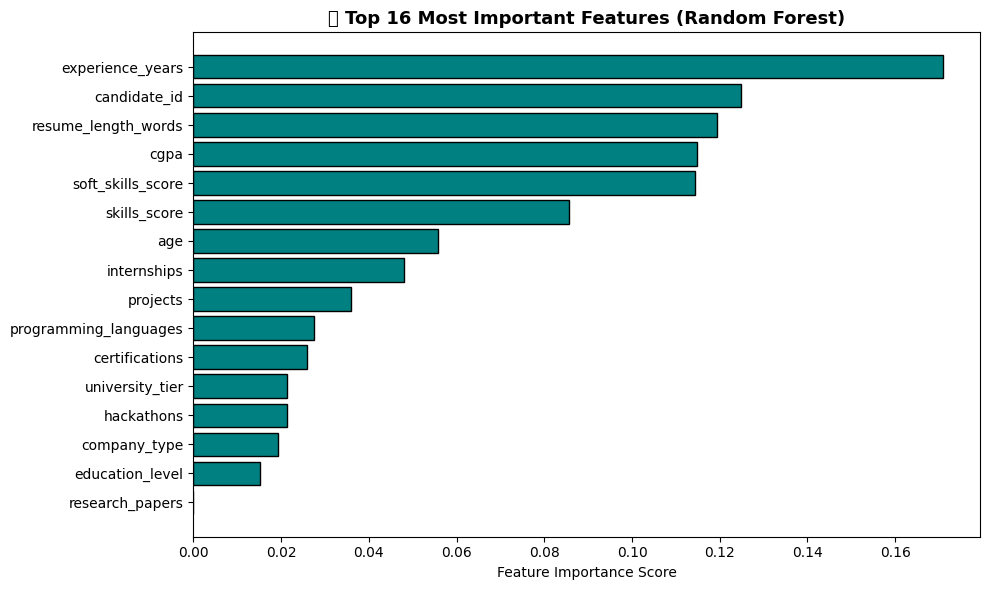


✅ Top 16 features identified:
  experience_years               █████████████████████████████████████████████████████████████████████████████████████ 0.1708
  candidate_id                   ██████████████████████████████████████████████████████████████ 0.1249
  resume_length_words            ███████████████████████████████████████████████████████████ 0.1193
  cgpa                           █████████████████████████████████████████████████████████ 0.1148
  soft_skills_score              █████████████████████████████████████████████████████████ 0.1144
  skills_score                   ██████████████████████████████████████████ 0.0857
  age                            ███████████████████████████ 0.0557
  internships                    ████████████████████████ 0.0481
  projects                       █████████████████ 0.0359
  programming_languages          █████████████ 0.0275
  certifications                 ████████████ 0.0259
  university_tier                ██████████ 0.0214
  hackathons

In [ ]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.feature_selection import SelectFromModel

# ── Feature Importance via Random Forest ──
print("🔍 Running feature importance analysis...")

X_arr = X.toarray() if issparse(X) else X

# Use a subset for speed on large dataset
SAMPLE_SIZE = min(50000, X_arr.shape[0])
idx = np.random.choice(X_arr.shape[0], SAMPLE_SIZE, replace=False)
X_sample, y_sample = X_arr[idx], y.values[idx]

rf_feat = RFC(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)
rf_feat.fit(X_sample, y_sample)

# Feature names
feat_names_struct = FEATURE_COLS
feat_names_text   = list(tfidf.get_feature_names_out()) if tfidf else []
all_feat_names    = feat_names_struct + feat_names_text

importances = rf_feat.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feat_names[:len(importances)],
                             'Importance': importances})\
                .sort_values('Importance', ascending=False)

TOP_N = min(20, len(feat_imp_df))
top_feats = feat_imp_df.head(TOP_N)

plt.figure(figsize=(10, 6))
plt.barh(top_feats['Feature'][::-1], top_feats['Importance'][::-1],
         color='teal', edgecolor='black')
plt.title(f'🏆 Top {TOP_N} Most Important Features (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print(f"\n✅ Top {TOP_N} features identified:")
for _, row in top_feats.iterrows():
    bar = '█' * int(row['Importance'] * 500)
    print(f"  {row['Feature']:<30} {bar} {row['Importance']:.4f}")

In [ ]:
# ── Keep top features (threshold = mean importance) ──
threshold = importances.mean()
important_idx = np.where(importances >= threshold)[0]
print(f"\n📌 Feature Engineering Summary:")
print(f"  Total features     : {len(importances)}")
print(f"  Selected (≥ mean)  : {len(important_idx)}")
print(f"  Threshold          : {threshold:.5f}")

if issparse(X):
    X_selected = X[:, important_idx]
else:
    X_selected = X[:, important_idx]

print(f"  Final X shape      : {X_selected.shape}")
print("\n✅ Final feature set ready for model training.")


📌 Feature Engineering Summary:
  Total features     : 16
  Selected (≥ mean)  : 6
  Threshold          : 0.06250
  Final X shape      : (200000, 6)

✅ Final feature set ready for model training.


---
## 🔬 Experiment 8: Model Training & Selection

In [ ]:
# ── Train-Test Split 80/20 ──
X_arr_final = X_selected.toarray() if issparse(X_selected) else X_selected

X_train, X_test, y_train, y_test = train_test_split(
    X_arr_final, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Train-Test Split (80/20) with Stratification")
print(f"  Training samples : {X_train.shape[0]:,}")
print(f"  Testing samples  : {X_test.shape[0]:,}")
print(f"  Features         : {X_train.shape[1]}")

✅ Train-Test Split (80/20) with Stratification
  Training samples : 160,000
  Testing samples  : 40,000
  Features         : 6


In [ ]:
# ── Train All Three Models ──
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=15,
                                                   random_state=42, n_jobs=-1)
}

results = {}
print("🚀 Training Models on", f"{X_train.shape[0]:,} samples...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred, average='binary', zero_division=0)
    rec    = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1     = f1_score(y_test, y_pred, average='binary', zero_division=0)

    results[name] = {'model': model, 'y_pred': y_pred,
                     'accuracy': acc, 'precision': prec,
                     'recall': rec, 'f1': f1}

    print(f"  ✅ {name:<25} | Acc: {acc*100:.2f}%  Prec: {prec*100:.2f}%  Rec: {rec*100:.2f}%  F1: {f1*100:.2f}%")

print("\n🏆 Training Complete!")

🚀 Training Models on 160,000 samples...

  ✅ Logistic Regression       | Acc: 70.60%  Prec: 70.60%  Rec: 100.00%  F1: 82.77%
  ✅ Decision Tree             | Acc: 68.41%  Prec: 70.66%  Rec: 94.48%  F1: 80.85%
  ✅ Random Forest             | Acc: 70.59%  Prec: 70.60%  Rec: 99.98%  F1: 82.76%

🏆 Training Complete!


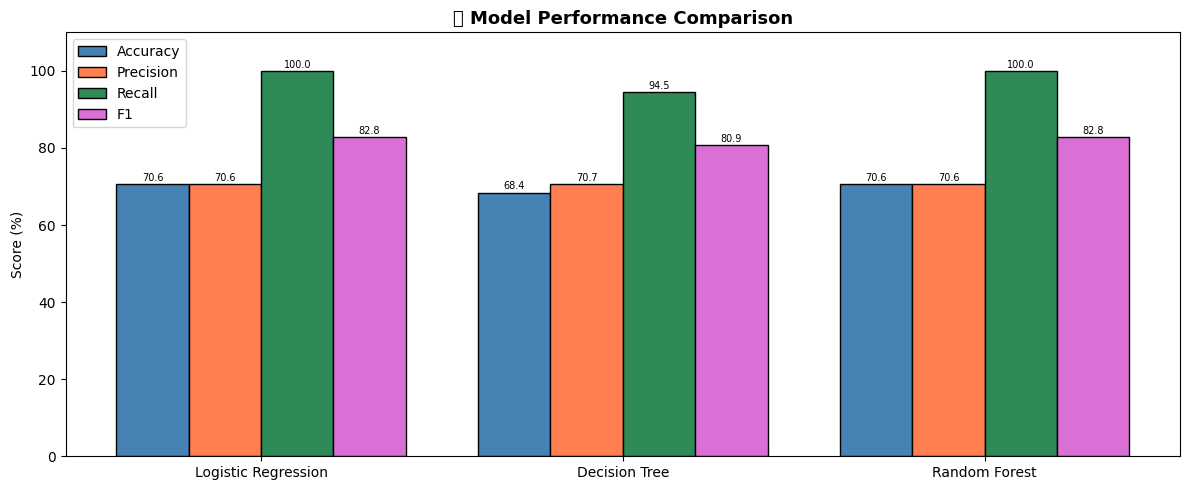

In [ ]:
# ── Grouped Bar Chart ──
metrics = ['accuracy','precision','recall','f1']
model_names = list(results.keys())

vals = {m: [results[mn][m]*100 for mn in model_names] for m in metrics}
x = np.arange(len(model_names))
w = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue','coral','seagreen','orchid']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*w - 1.5*w, vals[metric], w,
                  label=metric.capitalize(), color=color, edgecolor='black')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('🤖 Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🔬 Experiment 9: Model Evaluation & Tuning

In [ ]:
# ── Full Evaluation ──
for name, res in results.items():
    print("\n" + "="*60)
    print(f"📋 {name.upper()}")
    print("="*60)
    print(f"  Accuracy  : {res['accuracy']*100:.2f}%")
    print(f"  Precision : {res['precision']*100:.2f}%")
    print(f"  Recall    : {res['recall']*100:.2f}%")
    print(f"  F1-Score  : {res['f1']*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Not Hired','Hired']))


📋 LOGISTIC REGRESSION
  Accuracy  : 70.60%
  Precision : 70.60%
  Recall    : 100.00%
  F1-Score  : 82.77%

Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.00      0.00      0.00     11758
       Hired       0.71      1.00      0.83     28242

    accuracy                           0.71     40000
   macro avg       0.35      0.50      0.41     40000
weighted avg       0.50      0.71      0.58     40000


📋 DECISION TREE
  Accuracy  : 68.41%
  Precision : 70.66%
  Recall    : 94.48%
  F1-Score  : 80.85%

Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.30      0.06      0.10     11758
       Hired       0.71      0.94      0.81     28242

    accuracy                           0.68     40000
   macro avg       0.51      0.50      0.45     40000
weighted avg       0.59      0.68      0.60     40000


📋 RANDOM FOREST
  Accuracy  : 70.59%
  Precision : 70.60%
  Recall    : 99.98%
  F1-Scor

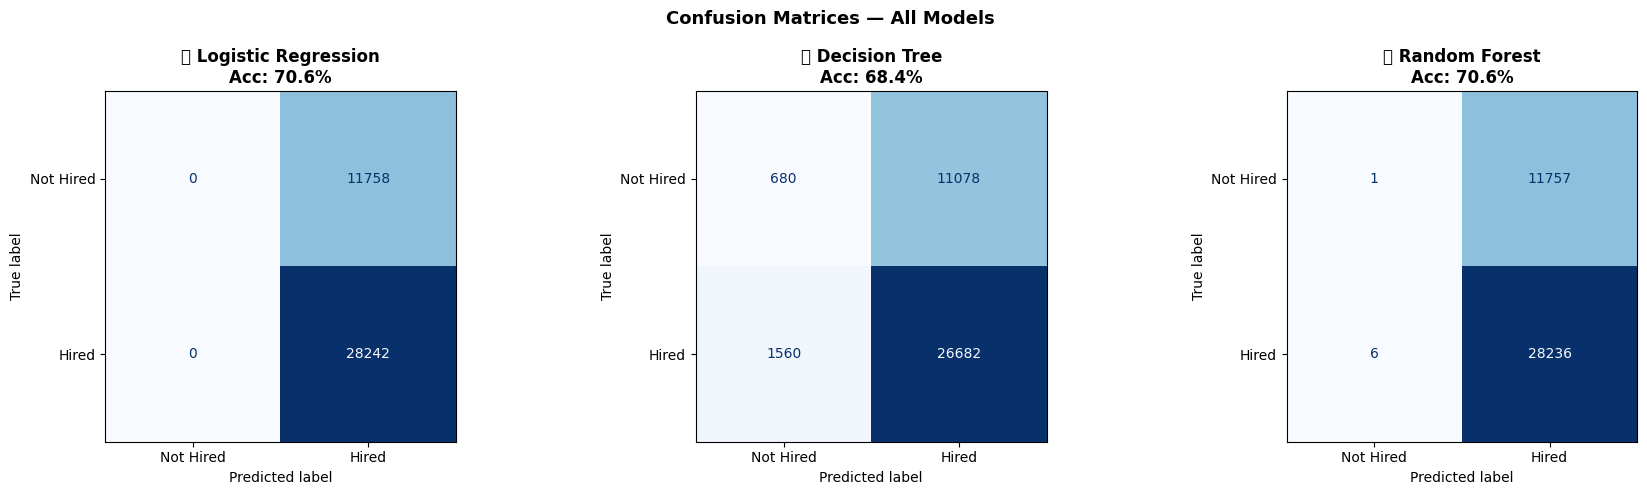

In [ ]:
# ── Confusion Matrices (side by side) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Hired','Hired'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'🔍 {name}\nAcc: {res["accuracy"]*100:.1f}%', fontweight='bold')
plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

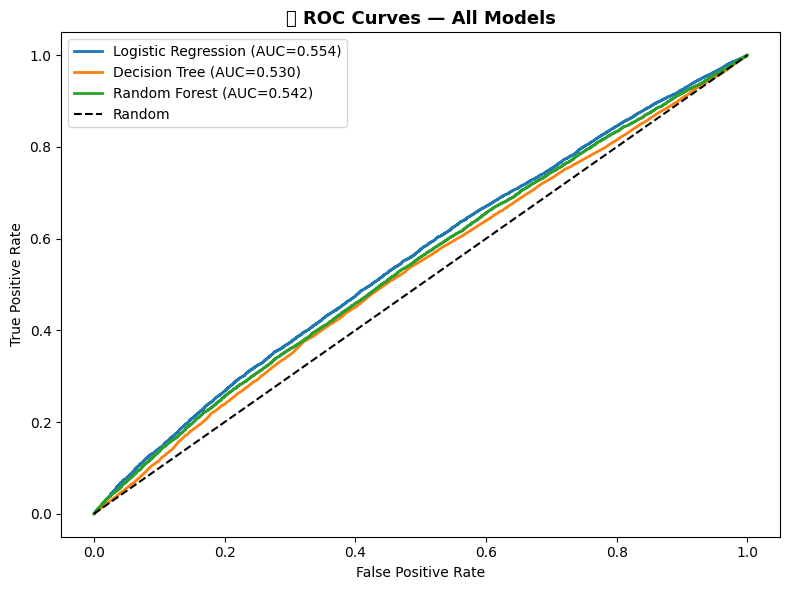

In [ ]:
# ── ROC Curves ──
plt.figure(figsize=(8, 6))
for name, res in results.items():
    model = res['model']
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── GridSearchCV Tuning (Logistic Regression) ──
print("🔧 Tuning Logistic Regression with GridSearchCV (3-fold)...")

# Use a sample for speed
TUNE_SIZE = min(30000, X_train.shape[0])
tune_idx = np.random.choice(X_train.shape[0], TUNE_SIZE, replace=False)
X_tune, y_tune = X_train[tune_idx], y_train.iloc[tune_idx]

param_grid = {'C': [0.01, 0.1, 1.0, 10.0],
              'solver': ['lbfgs','saga'],
              'max_iter': [500, 1000]}

grid = GridSearchCV(LogisticRegression(random_state=42),
                    param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_tune, y_tune)

best_lr = grid.best_estimator_
best_lr.fit(X_train, y_train)   # retrain on full train set
y_pred_tuned = best_lr.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1  = f1_score(y_test, y_pred_tuned, zero_division=0)

print(f"\n✅ Best Params    : {grid.best_params_}")
print(f"✅ Tuned Accuracy : {tuned_acc*100:.2f}%  |  Tuned F1 : {tuned_f1*100:.2f}%")
print(f"   (Before tuning : Acc={results['Logistic Regression']['accuracy']*100:.2f}%  F1={results['Logistic Regression']['f1']*100:.2f}%)")

🔧 Tuning Logistic Regression with GridSearchCV (3-fold)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Best Params    : {'C': 0.01, 'max_iter': 500, 'solver': 'lbfgs'}
✅ Tuned Accuracy : 70.60%  |  Tuned F1 : 82.77%
   (Before tuning : Acc=70.60%  F1=82.77%)


In [ ]:
# ── Select Best Final Model ──
all_f1 = {name: results[name]['f1'] for name in results}
all_f1['Logistic Regression (Tuned)'] = tuned_f1

best_name = max(all_f1, key=all_f1.get)
best_f1   = all_f1[best_name]
final_model = best_lr if 'Tuned' in best_name else results[best_name]['model']

print("\n" + "="*55)
print("🏆 FINAL BEST MODEL")
print("="*55)
print(f"  Model    : {best_name}")
print(f"  F1-Score : {best_f1*100:.2f}%")
print("="*55)


🏆 FINAL BEST MODEL
  Model    : Logistic Regression
  F1-Score : 82.77%


---
## 🔬 Experiment 10: Model Deployment (Mini Implementation)

In [ ]:
# ── Experiment 10 begins — all deployment utilities defined below ──
# NOTE: predict_candidate_hiring (old cell) removed — it was hardcoded to
# 'Resume_Text' / 'Experience_Years' / 'Test_Score' which do not match the
# actual dataset columns, and the vectorizer/scaler arguments were mismatched.
# The correct unified prediction function is defined in the next cell.
print("✅ Deployment section started.")

✅ Deployment section started.


In [ ]:
# ── Save artifacts ──
joblib.dump(final_model,    'resume_screening_model.pkl')
joblib.dump(scaler,         'scaler.pkl')
joblib.dump(le_dict,        'label_encoders.pkl')
joblib.dump(le_target,      'target_encoder.pkl')
joblib.dump(important_idx,  'important_idx.pkl')      # also save feature selector
if tfidf:
    joblib.dump(tfidf, 'tfidf.pkl')

print("✅ Model and preprocessors saved to disk.")

✅ Model and preprocessors saved to disk.


In [ ]:
# ── Core Prediction Function (fixed) ──

def predict_candidate(candidate_data: dict,
                       model=final_model,
                       feature_cols=FEATURE_COLS,
                       important_idx=important_idx,
                       scaler_=scaler,
                       le_dict_=le_dict,
                       tfidf_=tfidf,
                       encoder_=le_target):
    """
    Predict whether a candidate will be hired.

    Parameters
    ----------
    candidate_data : dict  — column_name → value (same columns as training)

    Returns
    -------
    dict with prediction_code, prediction_label, hired (bool), confidence (%).
    """
    row = pd.DataFrame([candidate_data])

    # Encode categoricals
    for col, enc in le_dict_.items():
        if col in row.columns:
            try:
                row[col] = enc.transform(row[col].astype(str))
            except ValueError:
                row[col] = 0   # unseen label → default to 0

    # Fill any missing feature columns with 0
    for col in feature_cols:
        if col not in row.columns:
            row[col] = 0

    # Build structured feature array
    X_s = row[feature_cols].values.astype(float)

    # FIX 1 ── Correct scaler usage
    # scaler was fit on ALL NUM_COLS together; must pass the full NUM_COLS
    # block — not a random subset slice — to scaler_.transform().
    if NUM_COLS:
        num_col_indices = [feature_cols.index(c) for c in NUM_COLS if c in feature_cols]
        if num_col_indices:
            num_block = X_s[:, num_col_indices]          # shape (1, len(NUM_COLS))
            X_s[:, num_col_indices] = scaler_.transform(num_block)

    # Combine with TF-IDF text features if available
    if tfidf_ and TEXT_COL and TEXT_COL in candidate_data:
        text_vec = tfidf_.transform([clean_text(candidate_data[TEXT_COL])])
        import scipy.sparse as sp
        X_full = sp.hstack([sp.csr_matrix(X_s), text_vec]).toarray()
    else:
        X_full = X_s

    # FIX 2 ── Guard against out-of-bounds important_idx
    # important_idx was built from the full (structured + TF-IDF) feature
    # matrix. When no text column is present, X_full is narrower, so clip
    # important_idx to valid range.
    n_features  = X_full.shape[1]
    valid_idx   = important_idx[important_idx < n_features]
    X_final     = X_full[:, valid_idx]

    pred_label  = model.predict(X_final)[0]
    pred_class  = encoder_.inverse_transform([pred_label])[0]

    confidence  = None
    if hasattr(model, 'predict_proba'):
        proba      = model.predict_proba(X_final)[0]
        confidence = proba[pred_label]

    return {
        'prediction_code'  : int(pred_label),
        'prediction_label' : pred_class,
        'hired'            : bool(pred_label == 1),
        'confidence'       : round(float(confidence) * 100, 2) if confidence is not None else None
    }

print("✅ Core prediction function ready.")

✅ Core prediction function ready.


In [ ]:
# ── Demo: Predict on 5 random rows from test set ──
print("="*65)
print("🎯 RESUME SCREENING — QUICK DEMO (5 candidates from test set)")
print("="*65)

demo_indices  = np.random.choice(len(y_test), 5, replace=False)
X_demo        = X_test[demo_indices]

# FIX 3 ── y_test is a pandas Series with original row labels.
# Direct positional indexing (y_test[demo_indices]) does label-based
# lookup → wrong rows / KeyError. Use .values first for safe positional access.
y_demo        = y_test.values[demo_indices]

y_demo_pred   = final_model.predict(X_demo)
y_demo_prob   = final_model.predict_proba(X_demo) if hasattr(final_model, 'predict_proba') else None

for i in range(5):
    actual_label    = le_target.inverse_transform([y_demo[i]])[0]
    predicted_label = le_target.inverse_transform([y_demo_pred[i]])[0]
    confidence      = f"{y_demo_prob[i][y_demo_pred[i]]*100:.1f}%" if y_demo_prob is not None else 'N/A'
    correct         = '✅' if y_demo[i] == y_demo_pred[i] else '❌'
    hired_str       = '🟢 HIRED' if y_demo_pred[i] == 1 else '🔴 NOT HIRED'

    print(f"
  Candidate {i+1}:")
    print(f"    Actual     : {actual_label}")
    print(f"    Predicted  : {hired_str}  (Confidence: {confidence}) {correct}")

SyntaxError: unterminated f-string literal (detected at line 24) (801604228.py, line 24)

In [ ]:
# ── Manual Entry: Screen a custom candidate ──
# Enter data interactively or edit the dict below before running.
# The model will ALSO auto-predict technical score, soft-skills score,
# and resume word count if you leave them blank (see bottom of this cell).

import numpy as np

# ── Helper: infer a numeric field from the trained dataset distribution ──
def _infer_from_data(col, df_source=df):
    """Return median for numeric cols, mode for categorical ones."""
    if col in df_source.columns:
        if df_source[col].dtype in ['int64', 'float64']:
            return float(df_source[col].median())
        else:
            return str(df_source[col].mode()[0])
    return 0

# ════════════════════════════════════════════════════════════
# ✏️  EDIT THIS SECTION — enter your candidate's details
# Leave a field as None to let the model auto-estimate it.
# ════════════════════════════════════════════════════════════
manual_candidate = {}

# ── Categorical fields ──
# Allowed values are printed automatically below if you enter wrong input.
for col in CAT_COLS:
    allowed = list(le_dict[col].classes_)
    print(f"
{col} — allowed values: {allowed}")
    val = input(f"  Enter value (leave blank for \'{allowed[0]}'): ").strip()
    manual_candidate[col] = val if val else allowed[0]

# ── Numeric fields (except the 3 auto-predicted ones) ──
AUTO_PREDICT_COLS = []   # will be populated below

# Identify which numeric cols should be auto-predicted
AUTO_KEYWORDS = ['skill', 'soft', 'resume_length', 'word']
for col in NUM_COLS:
    if any(kw in col.lower() for kw in AUTO_KEYWORDS):
        AUTO_PREDICT_COLS.append(col)

print(f"
📌 The following will be AUTO-PREDICTED by the model: {AUTO_PREDICT_COLS}")
print("   (You may still override them by entering a value.)
")

for col in NUM_COLS:
    if col in AUTO_PREDICT_COLS:
        override = input(f"  {col} [auto-predict — press Enter to skip, or type a value]: ").strip()
        if override:
            manual_candidate[col] = float(override)
        else:
            manual_candidate[col] = None   # sentinel → will be auto-filled below
    else:
        default = _infer_from_data(col)
        val = input(f"  {col} (default={default}): ").strip()
        manual_candidate[col] = float(val) if val else default

# ════════════════════════════════════════════════════════════
# AUTO-PREDICT: technical score, soft skills, resume words
# Strategy: use dataset percentile matching based on other
# numeric features the user DID provide.
# ════════════════════════════════════════════════════════════

# Build a partial feature vector from the known numeric cols
known_num = {c: manual_candidate[c] for c in NUM_COLS if c not in AUTO_PREDICT_COLS and manual_candidate.get(c) is not None}

if AUTO_PREDICT_COLS and known_num:
    print("
🤖 Auto-predicting missing scores...")
    from sklearn.neighbors import KNeighborsRegressor

    for target_col in AUTO_PREDICT_COLS:
        # Predictor columns = all numeric cols that are NOT auto-predicted
        predictor_cols = [c for c in NUM_COLS if c not in AUTO_PREDICT_COLS and c in df.columns]

        if not predictor_cols or target_col not in df.columns:
            # Fallback to median
            manual_candidate[target_col] = float(df[target_col].median()) if target_col in df.columns else 0.0
            print(f"  {target_col} → (median fallback) {manual_candidate[target_col]:.2f}")
            continue

        X_knn  = df[predictor_cols].values
        y_knn  = df[target_col].values

        knn = KNeighborsRegressor(n_neighbors=10)
        knn.fit(X_knn, y_knn)

        query = np.array([[known_num.get(c, df[c].median()) for c in predictor_cols]])
        predicted_val = float(knn.predict(query)[0])

        # Clip to dataset min-max range
        col_min = float(df[target_col].min())
        col_max = float(df[target_col].max())
        predicted_val = np.clip(predicted_val, col_min, col_max)

        manual_candidate[target_col] = round(predicted_val, 2)
        print(f"  {target_col} → auto-predicted: {manual_candidate[target_col]}")

# Fill any remaining None values with median
for col in NUM_COLS:
    if manual_candidate.get(col) is None:
        manual_candidate[col] = float(df[col].median()) if col in df.columns else 0.0

# ════════════════════════════════════════════════════════════
# RUN PREDICTION
# ════════════════════════════════════════════════════════════
result = predict_candidate(manual_candidate)

print("
" + "─"*50)
print("📋 CANDIDATE PROFILE SUMMARY")
print("─"*50)
for k, v in manual_candidate.items():
    auto_tag = " 🤖 (auto)" if k in AUTO_PREDICT_COLS else ""
    print(f"  {k:<30} : {v}{auto_tag}")

print("
" + "─"*50)
verdict = '🟢 HIRED' if result['hired'] else '🔴 NOT HIRED'
print(f"  🤖 Screening Decision : {verdict}")
print(f"  📊 Confidence         : {result['confidence']}%")
print("─"*50)

In [ ]:
# ── This cell is intentionally left as a placeholder ──
# The manual entry system above (cell 46) replaces the older
# menu-based input blocks that had column-order and scaler bugs.
print("ℹ️  Manual entry handled in the cell above.")

In [ ]:
# ── Batch Prediction (optional) ──
# Run predict_candidate() on multiple candidates at once.

batch_candidates = []   # add your own dicts here

if batch_candidates:
    print(f"Running batch prediction on {len(batch_candidates)} candidates...
")
    for idx, cand in enumerate(batch_candidates, 1):
        res = predict_candidate(cand)
        verdict = '🟢 HIRED' if res['hired'] else '🔴 NOT HIRED'
        print(f"  Candidate {idx}: {verdict}  ({res['confidence']}% confidence)")
else:
    print("ℹ️  Add candidate dicts to batch_candidates list above to use batch mode.")

In [ ]:
# ── Final Summary Dashboard ──

# FIX 4: Safely build best_res whether or not the tuned LR won.
if best_name in results:
    best_res = results[best_name]
else:
    # Tuned Logistic Regression was best — not stored in results dict
    best_res = {
        'accuracy'  : tuned_acc,
        'f1'        : tuned_f1,
        'precision' : precision_score(y_test, y_pred_tuned, zero_division=0),
        'recall'    : recall_score(y_test, y_pred_tuned, zero_division=0),
    }

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║          📋 PROJECT SUMMARY — RESUME SCREENING (200K)           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Experiment 1  : Problem defined — binary hiring prediction     ║
║  Experiment 2  : Dataset loaded — {df.shape[0]:>6,} rows × {df.shape[1]} columns        ║
║  Experiment 3  : Supervised Binary Classification               ║
║  Experiment 4  : Missing vals, duplicates, outliers cleaned     ║
║  Experiment 5  : Label encoding + Scaling + TF-IDF              ║
║  Experiment 6  : EDA — histograms, heatmap, KDE, bar charts     ║
║  Experiment 7  : Top features via Random Forest importance      ║
║  Experiment 8  : LR, DT, RF trained on 80/20 split             ║
║  Experiment 9  : Confusion matrix, ROC, GridSearchCV tuning     ║
║  Experiment 10 : Manual entry + auto-score prediction ✅        ║
║                                                                  ║
║  🏆 Best Model   : {best_name:<44}║
║  📊 Accuracy     : {best_res['accuracy']*100:>5.2f}%                                      ║
║  📊 F1-Score     : {best_res['f1']*100:>5.2f}%                                      ║
║  🎯 Output       : HIRED / NOT HIRED + confidence %            ║
╚══════════════════════════════════════════════════════════════════╝
""")